In [9]:
import os
import json
import sys
import pandas as pd
import time

def read_json(path):
    with open(path, 'r', encoding="utf-8") as f:
        data = json.load(f)
    return data

def write_json(data, path):
    if not os.path.exists(os.path.dirname(path)):
        os.makedirs(os.path.dirname(path))
    with open(path, 'w', encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)

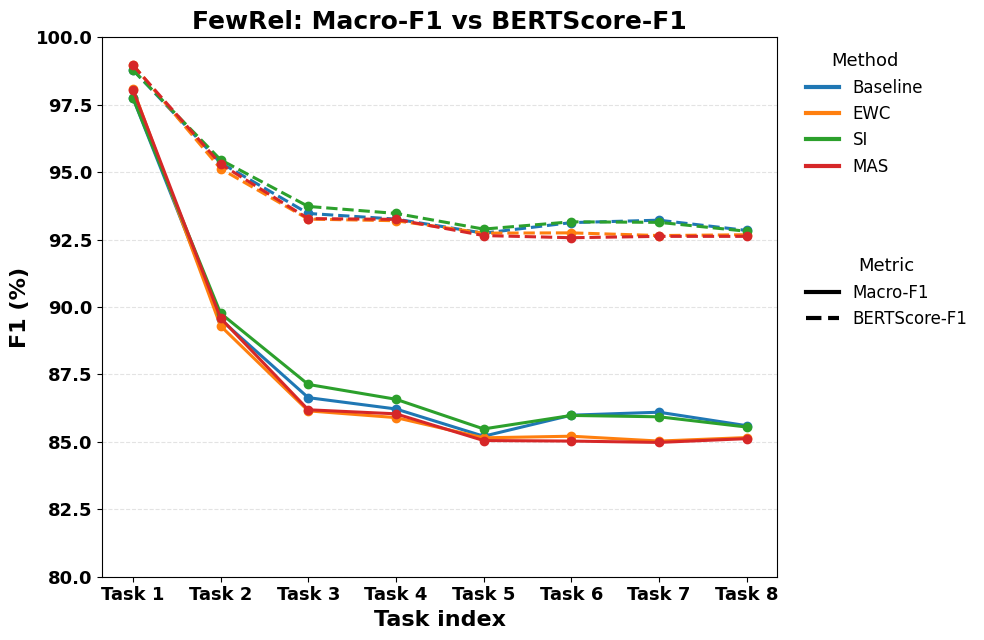

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# -------------------------
# DATA (FewRel)
# -------------------------
data = {
    "Tasks": [
        "Task 1","Task 2","Task 3","Task 4",
        "Task 5","Task 6","Task 7","Task 8"
    ],

    'Baseline F1':[97.76, 89.54, 86.64, 86.22, 85.21, 85.99, 86.10, 85.60],
    'Baseline BERTScore F1':[98.80, 95.35, 93.47, 93.26, 92.74, 93.13, 93.22, 92.84],

    'EWC F1':[98.10, 89.30, 86.15, 85.90, 85.15, 85.21, 85.03, 85.16],
    'EWC BERTScore F1':[98.99, 95.13, 93.26, 93.20, 92.74, 92.75, 92.65, 92.68],

    'SI F1':[97.76, 89.77, 87.13, 86.58, 85.48, 85.98, 85.93, 85.55],
    'SI BERTScore F1':[98.79, 95.46, 93.73, 93.47, 92.89, 93.16, 93.14, 92.81],

    'MAS F1':[98.06, 89.59, 86.19, 86.04, 85.05, 85.03, 84.98, 85.12],
    'MAS BERTScore F1':[98.97, 95.30, 93.28, 93.25, 92.65, 92.57, 92.62, 92.62],
}

df = pd.DataFrame(data)
df.set_index("Tasks", inplace=True)

# -------------------------
# Better encoding:
#   color = method, linestyle = metric
# -------------------------
methods = ["Baseline", "EWC", "SI", "MAS"]
method_colors = {
    "Baseline": "#1f77b4",
    "EWC": "#ff7f0e",
    "SI": "#2ca02c",
    "MAS": "#d62728",
}
metric_styles = {
    "F1": {"linestyle": "-",  "marker": "o"},
    "BERTScore F1": {"linestyle": "--", "marker": "o"},
}

# X axis as numeric positions (prevents ticklabel warnings)
tasks = df.index.tolist()
x = np.arange(len(tasks))

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(12.5, 6.5))

for m in methods:
    ax.plot(
        x, df[f"{m} F1"].values,
        color=method_colors[m],
        linewidth=2.2,
        **metric_styles["F1"]
    )
    ax.plot(
        x, df[f"{m} BERTScore F1"].values,
        color=method_colors[m],
        linewidth=2.2,
        **metric_styles["BERTScore F1"]
    )

# Title / labels
ax.set_title("FewRel: Macro-F1 vs BERTScore-F1", fontsize=18, fontweight="bold")
ax.set_xlabel("Task index", fontsize=16, fontweight="bold")
ax.set_ylabel("F1 (%)", fontsize=16, fontweight="bold")

# Ticks
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=13, fontweight="bold")

ax.tick_params(axis="y", labelsize=13)
for lab in ax.get_yticklabels():
    lab.set_fontweight("bold")

# Grid and range
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_ylim(80, 100)

# -------------------------
# Two clean legends: Method (colors) + Metric (styles)
# -------------------------
method_handles = [
    Line2D([0], [0], color=method_colors[m], lw=3, label=m)
    for m in methods
]
metric_handles = [
    Line2D([0], [0], color="black", lw=3, linestyle="-",  label="Macro-F1"),
    Line2D([0], [0], color="black", lw=3, linestyle="--", label="BERTScore-F1"),
]

leg1 = ax.legend(
    handles=method_handles,
    title="Method",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    fontsize=12,
    title_fontsize=13
)
ax.add_artist(leg1)

ax.legend(
    handles=metric_handles,
    title="Metric",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 0.62),
    fontsize=12,
    title_fontsize=13
)

fig.tight_layout(rect=[0, 0, 0.80, 1])
plt.savefig("fewrel_f1_bertscore_plot_better.pdf", dpi=300)
plt.show()


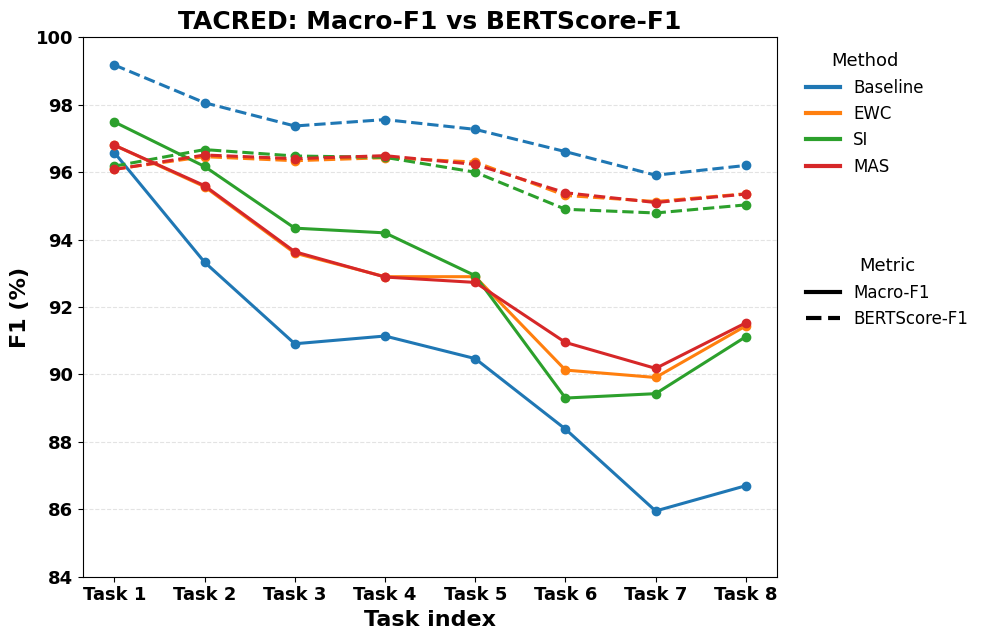

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# -------------------------
# DATA (TACRED)
# -------------------------
data = {
    "Tasks": [
        "Task 1","Task 2","Task 3","Task 4",
        "Task 5","Task 6","Task 7","Task 8"
    ],

    'Baseline F1':[96.58, 93.33, 90.91, 91.14, 90.47, 88.38, 85.95, 86.70],
    'Baseline BERTScore F1':[99.18, 98.06, 97.37, 97.56, 97.27, 96.61, 95.91, 96.20],

    'EWC F1':[96.80, 95.57, 93.60, 92.90, 92.90, 90.13, 89.91, 91.44],
    'EWC BERTScore F1':[96.09, 96.46, 96.34, 96.43, 96.30, 95.31, 95.13, 95.36],

    'SI F1':[97.49, 96.17, 94.34, 94.20, 92.93, 89.30, 89.43, 91.12],
    'SI BERTScore F1':[96.18, 96.67, 96.48, 96.44, 96.00, 94.90, 94.79, 95.03],

    'MAS F1':[96.80, 95.60, 93.64, 92.89, 92.73, 90.95, 90.18, 91.53],
    'MAS BERTScore F1':[96.08, 96.51, 96.40, 96.49, 96.23, 95.39, 95.10, 95.35],
}

df = pd.DataFrame(data)
df.set_index("Tasks", inplace=True)

# -------------------------
# Better encoding:
#   color = method, linestyle = metric
# -------------------------
methods = ["Baseline", "EWC", "SI", "MAS"]
method_colors = {
    "Baseline": "#1f77b4",
    "EWC": "#ff7f0e",
    "SI": "#2ca02c",
    "MAS": "#d62728",
}
metric_styles = {
    "F1": {"linestyle": "-",  "marker": "o"},
    "BERTScore F1": {"linestyle": "--", "marker": "o"},
}

# X axis as numeric positions (prevents ticklabel warnings)
tasks = df.index.tolist()
x = np.arange(len(tasks))

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(12.5, 6.5))

for m in methods:
    ax.plot(
        x, df[f"{m} F1"].values,
        color=method_colors[m],
        linewidth=2.2,
        **metric_styles["F1"],
        label=f"{m} (Macro-F1)"
    )
    ax.plot(
        x, df[f"{m} BERTScore F1"].values,
        color=method_colors[m],
        linewidth=2.2,
        **metric_styles["BERTScore F1"],
        label=f"{m} (BERTScore-F1)"
    )

# Labels & title
ax.set_title("TACRED: Macro-F1 vs BERTScore-F1", fontsize=18, fontweight="bold")
ax.set_xlabel("Task index", fontsize=16, fontweight="bold")
ax.set_ylabel("F1 (%)", fontsize=16, fontweight="bold")

# Proper ticks
ax.set_xticks(x)
ax.set_xticklabels(tasks, fontsize=13, fontweight="bold")

ax.tick_params(axis="y", labelsize=13)
for lab in ax.get_yticklabels():
    lab.set_fontweight("bold")

# Grid & limits
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_ylim(84, 100)

# -------------------------
# Cleaner legends: one for methods (colors), one for metrics (styles)
# -------------------------
method_handles = [
    Line2D([0], [0], color=method_colors[m], lw=3, label=m)
    for m in methods
]
metric_handles = [
    Line2D([0], [0], color="black", lw=3, linestyle="-",  label="Macro-F1"),
    Line2D([0], [0], color="black", lw=3, linestyle="--", label="BERTScore-F1"),
]

leg1 = ax.legend(handles=method_handles, title="Method", frameon=False,
                 loc="upper left", bbox_to_anchor=(1.02, 1.0),
                 fontsize=12, title_fontsize=13)
ax.add_artist(leg1)

ax.legend(handles=metric_handles, title="Metric", frameon=False,
          loc="upper left", bbox_to_anchor=(1.02, 0.62),
          fontsize=12, title_fontsize=13)

fig.tight_layout(rect=[0, 0, 0.80, 1])
plt.savefig("tacred_f1_bertscore_plot_better.pdf", dpi=300)
plt.show()
